# Auditing DeepIV — Relevance and Reliability: simulation core

**What this notebook is:** the empirical engine for the paper. It generates data where we *know the truth* (how strong the instrument is), then checks whether the **Wasserstein relevance index** correctly detects that strength. Known ground truth is why we simulate instead of hunting for real data.

**Variables:**
- `Z` = the instrument (a variable that pushes `X` but reaches `Y` only through `X`)
- `X` = the endogenous regressor (e.g. *order flow*, *a firm characteristic*)
- `Y` = the outcome (e.g. *returns*)
- `U` = a **hidden confounder** that entangles `X` and `Y` — this is the endogeneity IV exists to break
- `pi` = **instrument-strength knob**. `pi=0` → dead instrument; large `pi` → strong instrument

Run every cell top to bottom (Shift+Enter).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The data-generating process (the simulation)
`X` is built from the instrument `Z` (strength `pi`) plus the hidden confounder `U`.
`Y` is a **nonlinear** function of `X` — the nonlinearity is what justifies using DeepIV instead of linear IV — plus the same `U`, which creates the endogeneity.

In [2]:
def simulate(pi, n=6000, seed=0):
    rng = np.random.default_rng(seed)
    U  = rng.normal(size=n)              # hidden confounder
    Z  = rng.normal(size=n)              # instrument
    ex = rng.normal(size=n)
    ey = rng.normal(size=n)
    X  = pi*Z + U + ex                   # endogenous regressor; strength = pi
    Y  = np.sin(X) + 0.5*X + U + ey      # nonlinear h(X); U in Y => endogeneity
    return X, Y, Z

# quick look
X, Y, Z = simulate(pi=1.0)
print("shapes:", X.shape, Y.shape, Z.shape)
print("corr(Z, X) =", round(np.corrcoef(Z, X)[0,1], 3), " <- instrument moves X")
print("corr(X, Y) =", round(np.corrcoef(X, Y)[0,1], 3))

shapes: (6000,) (6000,) (6000,)
corr(Z, X) = 0.59  <- instrument moves X
corr(X, Y) = 0.786


## 2. Wasserstein relevance index ι
Idea: if `Z` matters, then the distribution of `X` *given a value of Z* should look different from the overall distribution of `X`. We measure that gap with the **squared 2-Wasserstein distance** (cost to reshape one distribution into another), average it across `Z`, and normalize.

- `w2_sq_1d` — squared 2-Wasserstein between two 1-D samples, via matching their quantiles.
- `iota` — bin `Z`, compare each bin's `X` to the overall `X`, average, divide by `2*Var(X)`.

**ι is outcome-agnostic.** It depends on `(X, Z)` only, never on `Y`. That makes it a *relevance* diagnostic rather than a validity test, and it is also the structural reason it cannot detect estimation failure on its own — nothing in ι sees the estimator, the outcome, or the ill-posedness of the inverse problem.

*(This is a simplified estimator for learning/validation. The paper's full version follows Borgonovo et al. 2024.)*

In [3]:
def w2_sq_1d(a, b, n_q=200):
    qs = (np.arange(n_q) + 0.5) / n_q
    return np.mean((np.quantile(a, qs) - np.quantile(b, qs))**2)

def iota(X, Z, n_bins=12):
    edges = np.quantile(Z, np.linspace(0, 1, n_bins+1))
    edges[0] -= 1e-9; edges[-1] += 1e-9
    num = 0.0
    for i in range(n_bins):
        m = (Z >= edges[i]) & (Z < edges[i+1])
        if m.sum() < 30:
            continue
        num += m.mean() * w2_sq_1d(X[m], X)
    return num / (2 * np.var(X))

## 3. Validation: does ι track the true instrument strength?
This is the core sanity check. Turn the knob `pi` from 0 (dead) upward; ι should start near 0 and rise.

In [4]:
pis = [0.0, 0.1, 0.3, 0.6, 1.0, 2.0, 4.0]
vals = []
print(f"{'pi (true strength)':>20} | {'iota (measured)':>16}")
print('-'*40)
for pi in pis:
    X, Y, Z = simulate(pi)
    v = iota(X, Z)
    vals.append(v)
    print(f"{pi:>20} | {v:>16.4f}")

  pi (true strength) |  iota (measured)
----------------------------------------
                 0.0 |           0.0019
                 0.1 |           0.0050
                 0.3 |           0.0252
                 0.6 |           0.0834
                 1.0 |           0.1857
                 2.0 |           0.4128
                 4.0 |           0.6336


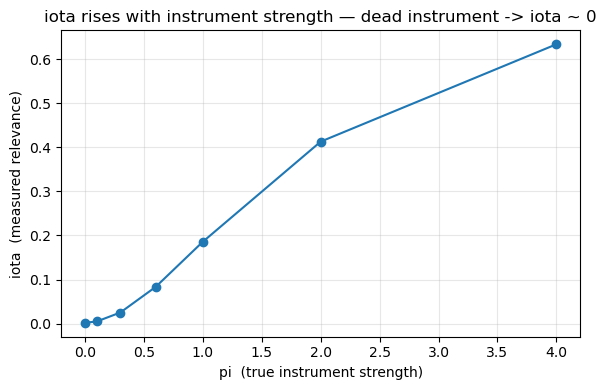

In [5]:
plt.figure(figsize=(6,4))
plt.plot(pis, vals, 'o-')
plt.xlabel('pi  (true instrument strength)')
plt.ylabel('iota  (measured relevance)')
plt.title('iota rises with instrument strength — dead instrument -> iota ~ 0')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Reading reliability *inside the black box*: S_boot and S_seed

In linear IV you read instrument strength straight off the first-stage coefficient / F-statistic. **DeepIV has no first-stage coefficient to test**, so we cannot audit reliability with a classical statistic. Instead, we look at how much the fitted structural function `h` moves under perturbation.

- **S_boot** — refit DeepIV on `B` bootstrap resamples of `(X, Y, Z)`; measure normalised disagreement among the fitted `h`-curves.
- **S_seed** — refit on the *same* data with different optimisation seeds; measure disagreement from optimisation alone.

**Why both.** S_boot alone conflates two very different things: sensitivity to the data, and noise from the optimiser. The paper's stronger reliability signals contrast them explicitly:

- **S_gap** = S_boot − S_seed (excess instability once optimiser noise is subtracted)
- **S_rel** = (S_boot − S_seed) / (S_seed + ε) (excess instability in units of the optimiser floor)
- **S_res** = S_boot − m̂(ι) (bootstrap instability with the relevance-explained part residualised out)

**Relevance and reliability are distinct axes.** They co-vary along π — which is what this notebook illustrates, and which is why the paper residualises one on the other — but they come apart along the ill-posedness axis κ, which ι is structurally blind to. In the paper's full grid, **relevance alone predicts failure at chance level (LOO-CV AUC 0.43); adding a reliability signal raises it to 0.69.**

**Degeneracy to guard against.** At the most ill-posed settings the bootstrap replicates agree on a smooth estimate that omits the oscillatory component of `h` entirely. They agree on the same wrong function, so S_boot can be small *exactly where the estimate is worst*. **Agreement among replicates certifies stability, not correctness.**

**Implementation note (why not `econml.iv.nnet.DeepIV`).** The original EconML `DeepIV` was built on TF1 / Keras-2 graph mode and was **removed** in econml ≥ 0.14 — `econml.iv.nnet` no longer exists under TensorFlow 2 / Keras 3. Rather than pin ancient dependencies, we implement DeepIV directly in **PyTorch**, faithful to the two-stage recipe of Hartford et al. (2017):

- **Stage 1** — a **mixture-density network (MDN)** models the conditional density `p(X | Z)`: a small net maps `Z` to the means, sigmas, and mixing weights of a Gaussian mixture over `X`.
- **Stage 2** — fit `h` by minimizing `E[(Y − E[h(X) | Z])²]`, where the inner expectation is taken over the Stage-1 density (approximated by sampling `X̃ ~ p̂(X | Z)`). Fitting `h` to the *conditional-mean* of `Y` given `Z` — not to `Y` given `X` — is exactly what removes the confounder `U` and makes this an IV estimator.

`h` is identified only up to an additive constant under this moment, so every curve is mean-centered before we compare them.

In [6]:
# ---- DeepIV in PyTorch (Hartford et al. 2017), self-contained ----
import torch, torch.nn as nn
torch.set_num_threads(4)

# Stage 1: mixture-density network for p(X | Z)
class MDN(nn.Module):
    def __init__(self, k=10, hidden=64):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(1, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU())
        self.pi   = nn.Linear(hidden, k)   # mixing logits
        self.mu   = nn.Linear(hidden, k)   # component means
        self.logs = nn.Linear(hidden, k)   # component log-sigmas
    def forward(self, z):
        h = self.body(z)
        return self.pi(h), self.mu(h), self.logs(h).clamp(-4, 3)

def _mdn_nll(pi_logits, mu, logs, x):
    logpi = torch.log_softmax(pi_logits, dim=1)
    comp  = -0.5*((x - mu)/torch.exp(logs))**2 - logs - 0.5*np.log(2*np.pi)
    return -torch.logsumexp(logpi + comp, dim=1).mean()

def fit_stage1(Z, X, epochs=200, lr=1e-2, seed=0):
    torch.manual_seed(seed)
    z = torch.tensor(Z, dtype=torch.float32).view(-1,1)
    x = torch.tensor(X, dtype=torch.float32).view(-1,1)
    net = MDN(); opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); _mdn_nll(*net(z), x).backward(); opt.step()
    return net

def sample_xgz(net, Z, n_samples, seed=0):
    torch.manual_seed(seed)
    z = torch.tensor(Z, dtype=torch.float32).view(-1,1)
    with torch.no_grad():
        pi_logits, mu, logs = net(z)
        w = torch.softmax(pi_logits, dim=1); idx = torch.arange(z.shape[0])
        cols = []
        for _ in range(n_samples):
            c = torch.multinomial(w, 1).squeeze(1)
            cols.append(mu[idx, c] + torch.exp(logs[idx, c])*torch.randn(z.shape[0]))
        return torch.stack(cols, dim=1)   # (n, n_samples)

# Stage 2: fit h(x) so that E[h(X)|Z] matches Y  (the IV moment)
class HNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

def fit_stage2(stage1, Z, Y, n_samples=5, epochs=200, lr=1e-2, seed=0):
    torch.manual_seed(seed)
    y  = torch.tensor(Y, dtype=torch.float32).view(-1,1)
    xs = sample_xgz(stage1, Z, n_samples, seed=seed)        # (n, S)
    h  = HNet(); opt = torch.optim.Adam(h.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        pred = h(xs.reshape(-1,1)).reshape(xs.shape).mean(dim=1, keepdim=True)  # E[h(X)|Z]
        ((y - pred)**2).mean().backward(); opt.step()
    return h

def fit_h(X, Y, Z, seed=0):
    """Full DeepIV: returns h_hat(x_grid) -> np.array of structural-function values."""
    s1 = fit_stage1(Z, X, seed=seed)
    h  = fit_stage2(s1, Z, Y, seed=seed)
    def h_hat(xg):
        xt = torch.tensor(np.asarray(xg, dtype=np.float32)).view(-1,1)
        with torch.no_grad():
            return h(xt).view(-1).numpy()
    return h_hat

# sanity: recover h(x) = sin(x) + 0.5x at a strong instrument
X, Y, Z = simulate(pi=1.0)
h_hat = fit_h(X, Y, Z, seed=0)
grid  = np.linspace(-3, 3, 41)
true  = np.sin(grid) + 0.5*grid
est   = h_hat(grid); est = est - est.mean() + true.mean()   # align the free constant
print("pi=1.0  RMSE(h_hat vs true h, mean-aligned) =",
      round(float(np.sqrt(np.mean((est - true)**2))), 3))

pi=1.0  RMSE(h_hat vs true h, mean-aligned) = 0.692


In [7]:
# ---- Reliability probes: S_boot, S_seed ----
GRID = np.linspace(-3, 3, 41)

def _dispersion(curves):
    """Normalised disagreement among a set of mean-centred h-curves."""
    C = np.stack(curves)
    return float(C.var(axis=0).mean() / (C.mean(axis=0).var() + 1e-8))

def s_boot(X, Y, Z, B=12, base_seed=0):
    """Refit DeepIV on B bootstrap resamples; disagreement of fitted h-curves."""
    n = len(X); rng = np.random.default_rng(base_seed)
    curves = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)                 # resample (X,Y,Z) jointly
        c = fit_h(X[idx], Y[idx], Z[idx], seed=base_seed + b)(GRID)
        curves.append(c - c.mean())                      # drop unidentified constant
    return _dispersion(curves)

def s_seed(X, Y, Z, R=12, base_seed=0):
    """Refit DeepIV on the SAME data with R different seeds; disagreement from
    optimisation alone."""
    curves = []
    for r in range(R):
        c = fit_h(X, Y, Z, seed=base_seed + 1000 + r)(GRID)
        curves.append(c - c.mean())
    return _dispersion(curves)

# smoke test
print("S_boot(pi=1.0) =", round(s_boot(*simulate(1.0), B=8), 4), " (expect small)")

S_boot(pi=1.0) = 0.0164  (expect small)


In [8]:
# ---- Validation: S_boot FALLS as the instrument strengthens (co-varies with iota along pi) ----
pis_rel = [0.0, 0.3, 0.6, 1.0, 2.0]
sboot_vals = []
print(f"{'pi (true strength)':>20} | {'S_boot (h-instability)':>24}")
print('-'*48)
for pi in pis_rel:
    v = s_boot(*simulate(pi), B=12)
    sboot_vals.append(v)
    print(f"{pi:>20} | {v:>24.4f}")

ratio = sboot_vals[0] / (sboot_vals[-1] + 1e-12)
print(f"\nS_boot falls by a factor of ~{ratio:,.0f} from a dead instrument (pi=0) to pi=2.")

  pi (true strength) |   S_boot (h-instability)
------------------------------------------------


                 0.0 |                   5.9992


                 0.3 |                   0.2719


                 0.6 |                   0.0488


                 1.0 |                   0.0222


                 2.0 |                   0.0073

S_boot falls by a factor of ~822 from a dead instrument (pi=0) to pi=2.


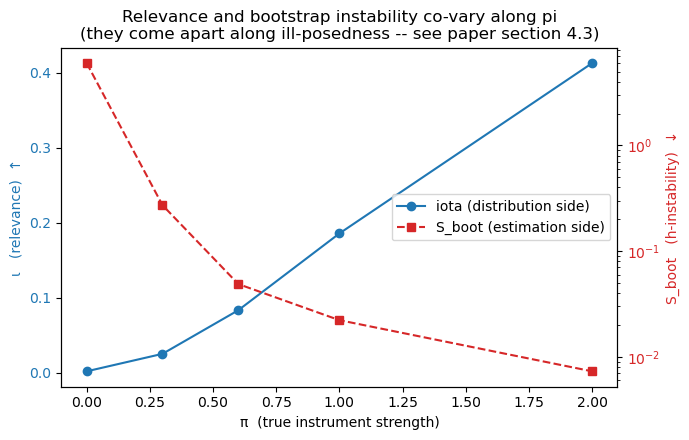

In [9]:
# ---- S_boot co-varies with relevance -- which is why the paper residualises it ----
iota_vals = []
for pi in pis_rel:
    Xi, Yi, Zi = simulate(pi)
    iota_vals.append(iota(Xi, Zi))

fig, ax1 = plt.subplots(figsize=(7,4.5))
l1, = ax1.plot(pis_rel, iota_vals, 'o-', color='tab:blue', label='iota (distribution side)')
ax1.set_xlabel('π  (true instrument strength)')
ax1.set_ylabel('ι   (relevance)  ↑', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
l2, = ax2.plot(pis_rel, sboot_vals, 's--', color='tab:red', label='S_boot (estimation side)')
ax2.set_ylabel('S_boot   (h-instability)  ↓', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_yscale('log')

ax1.legend(handles=[l1, l2], loc='center right', frameon=True)
plt.title('Relevance and bootstrap instability co-vary along pi\n(they come apart along ill-posedness -- see paper section 4.3)')
fig.tight_layout()
plt.show()

## 5. Optimisation noise is first order

S_boot is often read as *sensitivity to the data*, but for a deep pipeline that reading is wrong: the fitted `h` is **not a deterministic function of the data**. Refitting on the same sample with a different seed already moves the curve — different mini-batch order, different initialisation, different local optimum in a non-convex loss.

If **S_seed is of the same order as S_boot**, then a reliability signal built from resampling alone is measuring optimisation noise as much as data sensitivity. That is the whole argument for the paper's contrast statistics **S_gap = S_boot − S_seed** and **S_rel = (S_boot − S_seed) / (S_seed + ε)**: subtract the optimiser floor before you call what remains *data* sensitivity.

The table below prints all four at each π. Read S_seed as the floor, S_gap as the excess above it, S_rel as that excess in units of the floor.

**A caveat on the estimator, not the statistic.** With finite replicate counts (R, B in the low tens) the two dispersions are themselves noisy estimates, so S_gap can come out slightly negative at high relevance, where both quantities are small and nearly equal — as it does at π = 2 below. S_boot is bounded below by S_seed *in expectation*, since a bootstrap refit varies both the sample and the seed; a small negative value is estimation error in the statistic, not a finding.

In [1]:
EPS = 1e-8
print(f"{'pi':>6} | {'S_seed':>10} | {'S_boot':>10} | {'S_gap':>10} | {'S_rel':>10}")
print('-'*56)
for pi, sb in zip(pis_rel, sboot_vals):
    Xi, Yi, Zi = simulate(pi)
    ss  = s_seed(Xi, Yi, Zi, R=12)
    gap = sb - ss
    rel = (sb - ss) / (ss + EPS)
    print(f"{pi:>6} | {ss:>10.4f} | {sb:>10.4f} | {gap:>10.4f} | {rel:>10.4f}")

    pi |     S_seed |     S_boot |      S_gap |      S_rel
--------------------------------------------------------
   0.0 |     1.3797 |     5.9992 |     4.6195 |     3.3482
   0.3 |     0.1387 |     0.2719 |     0.1332 |     0.9602
   0.6 |     0.0436 |     0.0488 |     0.0052 |     0.1181
   1.0 |     0.0147 |     0.0222 |     0.0075 |     0.5124
   2.0 |     0.0078 |     0.0073 |    -0.0005 |    -0.0674


## 6. What this notebook does and does not establish

**Does.**
- ι is a clean monotone reading of instrument strength from `(X, Z)` alone.
- Bootstrap instability of the fitted `h` falls as the instrument strengthens, so the two co-vary along π.
- Seed variation is of the same order as bootstrap variation at weak instruments, and the two become indistinguishable at strong ones — which is why the paper's reliability signals subtract the seed floor before interpreting resampling scatter.

**Does not.**
- Nothing here shows that a reliability signal predicts estimation *failure* better than relevance does. That needs the paper's full grid (section 4.4): **60 independently fitted pipelines over 5 relevance levels × 4 ill-posedness levels × 3 seeds**, scored by leave-one-out cross-validated AUC against a known failure label. This notebook is the engine that grid is built from, run at one setting of κ and δ.

**Also not.**
- None of these statistics tests instrument *validity*. The exclusion restriction remains untestable; a high relevance score with a clean reliability profile says nothing about whether the instrument is legitimate.